<a href="https://colab.research.google.com/github/haribojjireddy/my-first-repo/blob/main/B2_Class_Imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the Packages

In [ ]:
!pip3 install imblearn

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

print("All libraries are installed")

All libraries are installed


# Load the data

In [ ]:
df = pd.read_csv("/content/creditcard_fraud.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.shape

(284807, 31)

In [ ]:
print("Target_Distributions")
print(df['Class'].value_counts())

print()

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count


print(f"Legitimate: {legit_count:,} ({legit_count/len(df)*100:.2f})")
print(f"Fraud:      {fraud_count:,} ({fraud_count/len(df)*100:.2f})")
print(f"\nImbalance Ratio: {legit_count//fraud_count}:1")

Target_Distributions
Class
0    284315
1       492
Name: count, dtype: int64

Legitimate: 284,315 (99.83)
Fraud:      492 (0.17)

Imbalance Ratio: 577:1


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-9.654937e-13,8.321385e-13,1.649999e-13,4.248366e-13,-3.054600e-13,8.777971e-14,-1.179749e-12,7.092545e-13,1.874948e-12,1.053347e-12,7.127611e-13,-1.474791e-13,-5.231558e-13,-2.282250e-13,-6.425436e-13,4.950748e-13,7.057397e-13,1.766111e-12,-3.405756e-13,-5.723197e-13,-9.725856e-13,1.464150e-12,-6.987102e-13,-5.617874e-13,3.332082e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Prepare the data for ml

In [ ]:
X = df.drop('Class', axis = 1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    stratify = y,
                                                    random_state = 42)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Train set: 227845 samples
Test set: 56962 samples


In [ ]:
print(f"\nTrain — Fraud: {y_train.sum()}, Legit: {(y_train==0).sum()}")
print(f"Test  — Fraud: {y_test.sum()}, Legit: {(y_test==0).sum()}")


Train — Fraud: 394, Legit: 227451
Test  — Fraud: 98, Legit: 56864


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Done")

Scaling Done


# Train logistic regresionmodel

In [ ]:
lr_naive = LogisticRegression(max_iter = 1000, random_state = 42)
lr_naive.fit(X_train_scaled, y_train)

y_pred_naive = lr_naive.predict(X_test_scaled)
y_prob_naive = lr_naive.predict_proba(X_test_scaled)[:,1]

# Evaluate the model

In [ ]:
print("=" * 60)
print("Naive Logistic regression - Results")
print("=" * 60)


acc = accuracy_score(y_test, y_pred_naive)
prec = precision_score(y_test, y_pred_naive)
rec = recall_score(y_test, y_pred_naive)
f1 = f1_score(y_test, y_pred_naive)
auc = roc_auc_score(y_test, y_prob_naive)

print(f"\n Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f" Precision:  {prec:.4f} ({prec*100:.2f}%)")
print(f" Recall:     {rec:.4f} ({rec*100:.2f}%)")
print(f" F1 Score:   {f1:.4f} ({f1*100:.2f}%)")
print(f" Auc:        {auc:.4f} ({auc*100:.2f}%)")

Naive Logistic regression - Results

 Accuracy: 0.9991 (99.91%)
 Precision:  0.8267 (82.67%)
 Recall:     0.6327 (63.27%)
 F1 Score:   0.7168 (71.68%)
 Auc:        0.9605 (96.05%)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_naive)
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix:")
print(f"                    Predicted")
print(f"                  Legit    Fraud")
print(f"  Actual Legit  [{tn:>6,}   {fp:>5,}]")
print(f"  Actual Fraud  [{fn:>6,}   {tp:>5,}]")

print(f"\n--- What This Means ---")
print(f"  True Negatives:  {tn:,} legit transactions correctly identified")
print(f"  False Positives: {fp:,} legit transactions wrongly flagged as fraud")
print(f"  True Positives:  {tp:,} frauds correctly caught ✅")
print(f"  False Negatives: {fn:,} FRAUDS MISSED! ❌")
print(f"\n  >>> The model MISSED {fn} out of {fn+tp} frauds ({fn/(fn+tp)*100:.1f}%) <<<")
print(f"  >>> The bank loses money on {fn} undetected fraudulent transactions! <<<")


Confusion Matrix:
                    Predicted
                  Legit    Fraud
  Actual Legit  [56,851      13]
  Actual Fraud  [    36      62]

--- What This Means ---
  True Negatives:  56,851 legit transactions correctly identified
  False Positives: 13 legit transactions wrongly flagged as fraud
  True Positives:  62 frauds correctly caught ✅
  False Negatives: 36 FRAUDS MISSED! ❌

  >>> The model MISSED 36 out of 98 frauds (36.7%) <<<
  >>> The bank loses money on 36 undetected fraudulent transactions! <<<


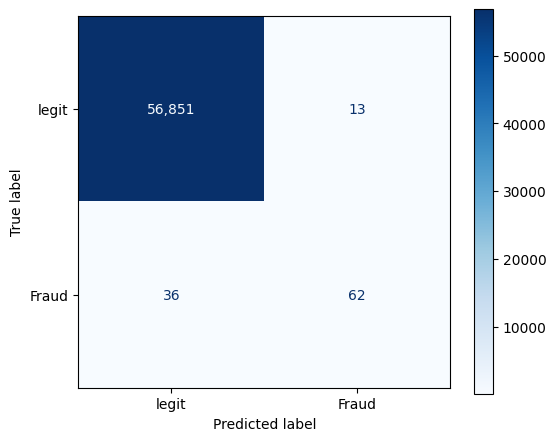

In [ ]:
fig, ax = plt.subplots(figsize = (6,5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_naive,
    display_labels = ['legit', 'Fraud'],
    cmap = "Blues",
    ax=ax,
    values_format=','
)
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_naive, target_names=['Legit', 'Fraud']))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



# Resampling Techniques and evalute and compare models

- Class weights - More importance to minority class
- Random Undersampling - Removes a lot of data to balance it
- SMOTE(over sampling) - Creting synthetic minorty class samples

In [ ]:
lr_balanced = LogisticRegression(max_iter=1000,
                                 random_state = 42,
                                 class_weight="balanced")
lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:,1]

cm = confusion_matrix(y_test, y_pred_bal)
tn_b, fp_b, fn_b, tp_b = cm.ravel()

print("=" * 60)
print("FIX #1: class_weight='balanced'")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_bal):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_bal):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_bal):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_bal):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_bal):.4f}")
print(f"\n  Frauds caught: {tp_b} out of {tp_b+fn_b} ({tp_b/(tp_b+fn_b)*100:.1f}%)")
print(f"  Frauds missed: {fn_b} ({fn_b/(tp_b+fn_b)*100:.1f}%)")
print(f"  False alarms:  {fp_b} legit transactions wrongly flagged")

FIX #1: class_weight='balanced'
  Accuracy:  0.9755
  Precision: 0.0610
  Recall:    0.9184
  F1-Score:  0.1144
  ROC-AUC:   0.9721

  Frauds caught: 90 out of 98 (91.8%)
  Frauds missed: 8 (8.2%)
  False alarms:  1386 legit transactions wrongly flagged


# Random Undersampling

In [ ]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print("Random Undersampling")
print(f" Before: Legit={int((y_train==0).sum()):,}, Fraud={int(y_train.sum())}")
print(f" After: Legit={int((y_train_under==0).sum()):,}, Fraud={int(y_train_under.sum())}")
print(f" Threw Away {len(y_train)- len(y_train_under):,} Majority samples")

Random Undersampling
 Before: Legit=227,451, Fraud=394
 After: Legit=394, Fraud=394
 Threw Away 227,057 Majority samples


In [ ]:
X_test_scaled.shape

(56962, 30)

In [ ]:
lr_under = LogisticRegression(max_iter=1000,
                                 random_state = 42,
                                )
lr_under.fit(X_train_under, y_train_under)

y_pred_under = lr_under.predict(X_test_scaled)
y_prob_under = lr_under.predict_proba(X_test_scaled)[:,1]

cm = confusion_matrix(y_test, y_pred_under)
tn_u, fp_u, fn_u, tp_u = cm.ravel()

print("=" * 60)
print("FIX #1: class_weight='balanced'")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_under):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_under):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_under):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_under):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_under):.4f}")
print(f"\n  Frauds caught: {tp_u} out of {tp_u+fn_u} ({tp_u/(tp_u+fn_u)*100:.1f}%)")
print(f"  Frauds missed: {fn_u} ({fn_u/(tp_u+fn_u)*100:.1f}%)")
print(f"  False alarms:  {fp_u} legit transactions wrongly flagged")

FIX #1: class_weight='balanced'
  Accuracy:  0.9602
  Precision: 0.0383
  Recall:    0.9184
  F1-Score:  0.0736
  ROC-AUC:   0.9761

  Frauds caught: 90 out of 98 (91.8%)
  Frauds missed: 8 (8.2%)
  False alarms:  2258 legit transactions wrongly flagged


In [ ]:
cm

array([[54606,  2258],
       [    8,    90]])

# SMOTE Approach

- Synthetic Minoroty Over Sampling technique

## How Smote works
- It will pick a fraud sample
- find it K nearest fraud neighbours
- creayte a new synthieci fraud sample somewere near to the fraud sample.


In [ ]:
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Over Sampling Technique - SMOTE")
print(f" Before: Legit={int((y_train==0).sum()):,}, Fraud={int(y_train.sum())}")
print(f" After: Legit={int((y_train_smote==0).sum()):,}, Fraud={int(y_train_smote.sum())}")
print(f" Created {len(y_train_smote)- len(y_train):,} synthetic fraud samples")

Over Sampling Technique - SMOTE
 Before: Legit=227,451, Fraud=394
 After: Legit=227,451, Fraud=227451
 Created 227,057 synthetic fraud samples


In [ ]:
lr_smote = LogisticRegression(max_iter= 1000, random_state = 42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:,1]

cm_smote = confusion_matrix(y_test, y_pred_smote)
tn_s, fp_s, fn_s, tp_s = cm_smote.ravel()

print("=" * 60)
print("FIX #3: SMOTE (Full Oversampling)")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_smote):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_smote):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_smote):.4f}")
print(f"\n  Frauds caught: {tp_s} out of {tp_s+fn_s} ({tp_s/(tp_s+fn_s)*100:.1f}%)")
print(f"  Frauds missed: {fn_s}")
print(f"  False alarms:  {fp_s:,}")

FIX #3: SMOTE (Full Oversampling)
  Accuracy:  0.9741
  Precision: 0.0578
  Recall:    0.9184
  F1-Score:  0.1088
  ROC-AUC:   0.9708

  Frauds caught: 90 out of 98 (91.8%)
  Frauds missed: 8
  False alarms:  1,467


# Smote with Sampling strategy

In [ ]:
smote_partial = SMOTE(sampling_strategy=0.1, random_state = 42)
X_train_sp, y_train_sp = smote_partial.fit_resample(X_train_scaled, y_train)

print("SMOTE (10% ratio)")
print(f" Before: Legit={int((y_train==0).sum()):,}, Fraud={int(y_train.sum())}")
print(f" After: Legit={int((y_train_sp==0).sum()):,}, Fraud={int(y_train_sp.sum())}")

SMOTE (10% ratio)
 Before: Legit=227,451, Fraud=394
 After: Legit=227,451, Fraud=22745


In [ ]:
lr_sp = LogisticRegression(max_iter=1000, random_state=42)
lr_sp.fit(X_train_sp, y_train_sp)

y_pred_sp = lr_sp.predict(X_test_scaled)
y_prob_sp = lr_sp.predict_proba(X_test_scaled)[:,1]

cm_sp = confusion_matrix(y_test, y_pred_sp)
tn_sp, fp_sp, fn_sp, tp_sp = cm_sp.ravel()

print(f"\n  Accuracy:  {accuracy_score(y_test, y_pred_sp):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sp):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_sp):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_sp):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob_sp):.4f}")
print(f"\n  Frauds caught: {tp_sp} out of {tp_sp+fn_sp} ({tp_sp/(tp_sp+fn_sp)*100:.1f}%)")
print(f"  Frauds missed: {fn_sp}")
print(f"  False alarms:  {fp_sp}")


  Accuracy:  0.9970
  Precision: 0.3522
  Recall:    0.8878
  F1-Score:  0.5043
  ROC-AUC:   0.9674

  Frauds caught: 87 out of 98 (88.8%)
  Frauds missed: 11
  False alarms:  160


In [ ]:
# Compare all methods
print(f"{'Method':<28} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Missed':>8}")
print("-" * 75)

results = [
    ("Naive LogReg", y_pred_naive, y_prob_naive, fn),
    ("class_weight='balanced'", y_pred_bal, y_prob_bal, fn_b),
    ("Undersampling", y_pred_under, y_prob_under, fn_u),
    ("SMOTE (full)", y_pred_smote, y_prob_smote, fn_s),
    ("SMOTE (10%)", y_pred_sp, y_prob_sp, fn_sp),
]

for name, y_p, y_pr, missed in results:
    print(f"{name:<28} {accuracy_score(y_test, y_p):>9.4f} "
          f"{precision_score(y_test, y_p):>10.4f} "
          f"{recall_score(y_test, y_p):>8.4f} "
          f"{f1_score(y_test, y_p):>8.4f} "
          f"{missed:>8}")

Method                        Accuracy  Precision   Recall       F1   Missed
---------------------------------------------------------------------------
Naive LogReg                    0.9991     0.8267   0.6327   0.7168        8
class_weight='balanced'         0.9755     0.0610   0.9184   0.1144        8
Undersampling                   0.9602     0.0383   0.9184   0.0736        8
SMOTE (full)                    0.9741     0.0578   0.9184   0.1088        8
SMOTE (10%)                     0.9970     0.3522   0.8878   0.5043       11
